# Experiment 1: Data Collection and Preprocessing Techniques

**Objective:**  
Understand the process of data collection and preprocessing, including:
- Handling missing values
- Normalizing and scaling data
- Encoding categorical variables

**Dataset:** `resume_dataset_200k_enhanced.csv`  
**Language:** Python only

---
## Table of Contents
1. Import Libraries
2. Step 1 — Load the Dataset
3. Step 2 — Inspect the Dataset
4. Step 3 — Handle Missing Values (Deletion)
5. Step 4 — Normalize Data (Min-Max Scaling)
6. Step 5 — Standardize Data (Z-score)
7. Step 6 — Encode Categorical Variables (One-Hot Encoding)
8. Step 7 — Encode Categorical Variables (Label Encoding)
9. Step 8 — Visualize Before & After Preprocessing

## 1. Import Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print('All libraries imported successfully.')

All libraries imported successfully.


## Step 1 — Load the Dataset

Load the CSV file using `pandas.read_csv()`.

In [38]:
data = pd.read_csv('resume_dataset_200k_enhanced.csv')
print('Dataset loaded successfully.')
print('Shape:', data.shape)

Dataset loaded successfully.
Shape: (200000, 17)


## Step 2 — Inspect the Dataset

Check the first few rows, column types, and basic structure.

In [39]:
data.head()

,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
0,1,27,Bachelors,Tier 2,8.1600,2,7,2,2,0.3300,0,0,21.0000,1,5.6200,409,MNC
1,2,24,Bachelors,Tier 3,6.3500,3,2,2,2,4.9900,0,0,11.0000,1,9.6600,237,Startup
2,3,33,Bachelors,Tier 3,7.7800,0,2,4,2,0.9300,0,0,15.0000,1,8.1200,435,Startup
3,4,31,Masters,Tier 3,6.9200,2,1,4,1,0.3700,0,0,11.5000,1,7.1900,340,MNC
4,5,28,Masters,Tier 2,8.2400,3,0,1,2,0.3300,0,0,5.0000,0,4.0900,371,Mid-size


In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   candidate_id           200000 non-null  int64  
 1   age                    200000 non-null  int64  
 2   education_level        200000 non-null  object 
 3   university_tier        200000 non-null  object 
 4   cgpa                   200000 non-null  float64
 5   internships            200000 non-null  int64  
 6   projects               200000 non-null  int64  
 7   programming_languages  200000 non-null  int64  
 8   certifications         200000 non-null  int64  
 9   experience_years       200000 non-null  float64
 10  hackathons             200000 non-null  int64  
 11  research_papers        200000 non-null  int64  
 12  skills_score           200000 non-null  float64
 13  hired                  200000 non-null  int64  
 14  soft_skills_score      200000 non-nu

In [41]:
data.describe()

,candidate_id,age,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words
count,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000
mean,100000.5000,27.5117,7.4993,1.5030,2.9962,3.0044,1.0010,1.4990,0.4980,0.2019,14.0008,0.7061,6.5029,449.2070
std,57735.1713,4.0307,0.8010,1.2254,1.7311,1.4122,1.0022,1.4975,0.7068,0.4488,4.7663,0.4556,2.0196,120.1031
min,1.0000,21.0000,4.1500,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,2.0000,0.0000,3.0000,-79.0000
25%,50000.7500,24.0000,6.9600,1.0000,2.0000,2.0000,0.0000,0.4300,0.0000,0.0000,10.5000,0.0000,4.7500,368.0000
50%,100000.5000,28.0000,7.5000,1.0000,3.0000,3.0000,1.0000,1.0400,0.0000,0.0000,14.0000,1.0000,6.5100,449.0000
75%,150000.2500,31.0000,8.0400,2.0000,4.0000,4.0000,2.0000,2.0800,1.0000,0.0000,17.0000,1.0000,8.2500,530.0000
max,200000.0000,34.0000,11.2300,10.0000,14.0000,5.0000,8.0000,23.5500,6.0000,5.0000,38.5000,1.0000,10.0000,956.0000


## Step 3 — Handle Missing Values (Deletion)

Check how many missing values exist per column, then drop rows that contain any.

In [42]:
print('Missing values per column:')
print(data.isnull().sum())

Missing values per column:
candidate_id             0
age                      0
education_level          0
university_tier          0
cgpa                     0
internships              0
projects                 0
programming_languages    0
certifications           0
experience_years         0
hackathons               0
research_papers          0
skills_score             0
hired                    0
soft_skills_score        0
resume_length_words      0
company_type             0
dtype: int64


In [43]:
data_cleaned = data.dropna()
print('Shape before dropna:', data.shape)
print('Shape after  dropna:', data_cleaned.shape)

Shape before dropna: (200000, 17)
Shape after  dropna: (200000, 17)


## Step 4 — Normalize Data (Min-Max Scaling)

Rescales features to the range **[0, 1]**.  
Formula: `x_norm = (x - min) / (max - min)`

In [44]:
scale_cols = ['age', 'cgpa', 'experience_years', 'skills_score',
              'soft_skills_score', 'resume_length_words']

scaler_mm = MinMaxScaler()
data_normalized = data_cleaned.copy()
data_normalized[scale_cols] = scaler_mm.fit_transform(data_cleaned[scale_cols])

print('Min-Max Normalized (first 3 rows):')
data_normalized[scale_cols].head(3)

Min-Max Normalized (first 3 rows):


,age,cgpa,experience_years,skills_score,soft_skills_score,resume_length_words
0,0.4615,0.5664,0.0140,0.5205,0.3743,0.4715
1,0.2308,0.3107,0.2119,0.2466,0.9514,0.3053
2,0.9231,0.5127,0.0395,0.3562,0.7314,0.4966


## Step 5 — Standardize Data (Z-score / StandardScaler)

Rescales features to have **mean = 0** and **std = 1**.  
Formula: `x_std = (x - mean) / std`

In [45]:
scaler_std = StandardScaler()
data_standardized = data_cleaned.copy()
data_standardized[scale_cols] = scaler_std.fit_transform(data_cleaned[scale_cols])

print('Standardized stats (mean ~0, std ~1):')
data_standardized[scale_cols].describe().loc[['mean', 'std']]

Standardized stats (mean ~0, std ~1):


,age,cgpa,experience_years,skills_score,soft_skills_score,resume_length_words
mean,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


## Step 6 — Encode Categorical Variables: One-Hot Encoding

Converts each category into a separate binary (0/1) column.  
Best for **nominal** categories with no natural order.

In [46]:
data_ohe = data_cleaned.copy()
data_ohe = pd.get_dummies(data_ohe, columns=['education_level', 'university_tier', 'company_type'])

print('Shape after One-Hot Encoding:', data_ohe.shape)
print('New columns:', [c for c in data_ohe.columns if any(
    c.startswith(p) for p in ['education_level_', 'university_tier_', 'company_'])])
data_ohe.head(3)

Shape after One-Hot Encoding: (200000, 23)
New columns: ['education_level_Bachelors', 'education_level_Masters', 'education_level_PhD', 'university_tier_Tier 1', 'university_tier_Tier 2', 'university_tier_Tier 3', 'company_type_MNC', 'company_type_Mid-size', 'company_type_Startup']


,candidate_id,age,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,education_level_Bachelors,education_level_Masters,education_level_PhD,university_tier_Tier 1,university_tier_Tier 2,university_tier_Tier 3,company_type_MNC,company_type_Mid-size,company_type_Startup
0,1,27,8.1600,2,7,2,2,0.3300,0,0,21.0000,1,5.6200,409,True,False,False,False,True,False,True,False,False
1,2,24,6.3500,3,2,2,2,4.9900,0,0,11.0000,1,9.6600,237,True,False,False,False,False,True,False,False,True
2,3,33,7.7800,0,2,4,2,0.9300,0,0,15.0000,1,8.1200,435,True,False,False,False,False,True,False,False,True


## Step 7 — Encode Categorical Variables: Label Encoding

Converts each category to a single integer value.  
Best for **ordinal** categories (e.g., Tier 1 > Tier 2 > Tier 3).

In [47]:
data_le = data_cleaned.copy()
le = LabelEncoder()

for col in ['education_level', 'university_tier', 'company_type']:
    data_le[f'{col}_encoded'] = le.fit_transform(data_le[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'{col} mapping: {mapping}')

data_le[['education_level', 'education_level_encoded',
         'university_tier', 'university_tier_encoded',
         'company_type', 'company_type_encoded']].head(5)

education_level mapping: {'Bachelors': np.int64(0), 'Masters': np.int64(1), 'PhD': np.int64(2)}
university_tier mapping: {'Tier 1': np.int64(0), 'Tier 2': np.int64(1), 'Tier 3': np.int64(2)}
company_type mapping: {'MNC': np.int64(0), 'Mid-size': np.int64(1), 'Startup': np.int64(2)}


,education_level,education_level_encoded,university_tier,university_tier_encoded,company_type,company_type_encoded
0,Bachelors,0,Tier 2,1,MNC,0
1,Bachelors,0,Tier 3,2,Startup,2
2,Bachelors,0,Tier 3,2,Startup,2
3,Masters,1,Tier 3,2,MNC,0
4,Masters,1,Tier 2,1,Mid-size,1


## Step 8 — Visualize Before & After Preprocessing

Compare distributions before and after normalization and standardization.

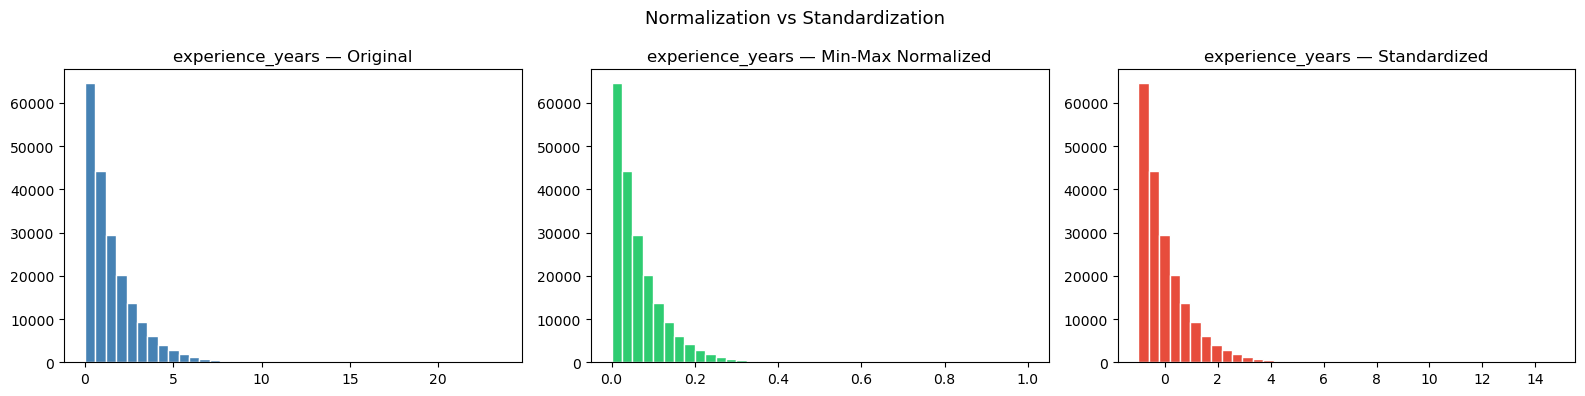

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(data_cleaned['experience_years'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('experience_years — Original')

axes[1].hist(data_normalized['experience_years'], bins=40, color='#2ecc71', edgecolor='white')
axes[1].set_title('experience_years — Min-Max Normalized')

axes[2].hist(data_standardized['experience_years'], bins=40, color='#e74c3c', edgecolor='white')
axes[2].set_title('experience_years — Standardized')

plt.suptitle('Normalization vs Standardization', fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\suhan\AppData\Local\Temp\ipykernel_12412\2475773648.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([data_cleaned['cgpa'], data_cleaned['skills_score'],
C:\Users\suhan\AppData\Local\Temp\ipykernel_12412\2475773648.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([data_normalized['cgpa'], data_normalized['skills_score'],


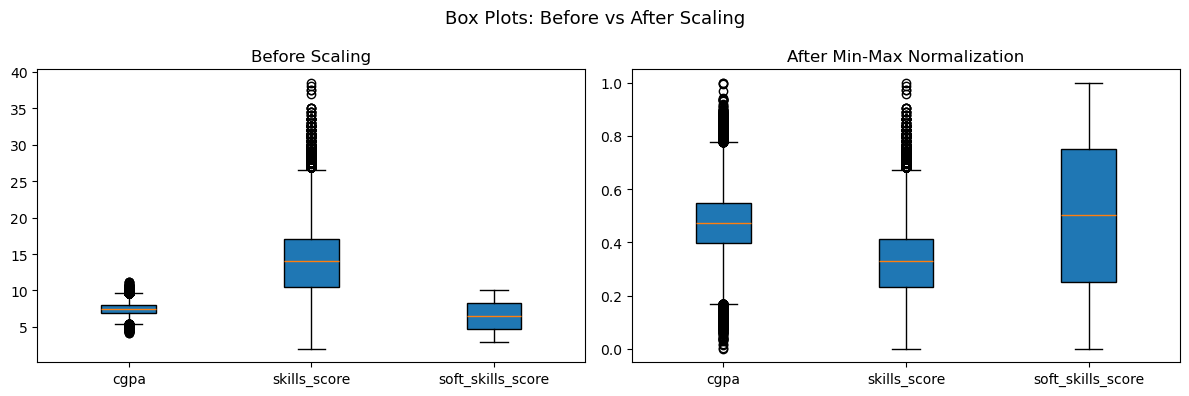

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot([data_cleaned['cgpa'], data_cleaned['skills_score'],
                 data_cleaned['soft_skills_score']],
                labels=['cgpa', 'skills_score', 'soft_skills_score'],
                patch_artist=True)
axes[0].set_title('Before Scaling')

axes[1].boxplot([data_normalized['cgpa'], data_normalized['skills_score'],
                 data_normalized['soft_skills_score']],
                labels=['cgpa', 'skills_score', 'soft_skills_score'],
                patch_artist=True)
axes[1].set_title('After Min-Max Normalization')

plt.suptitle('Box Plots: Before vs After Scaling', fontsize=13)
plt.tight_layout()
plt.show()

---
## Conclusion

This experiment demonstrated the essential steps of data preprocessing:

| Step | Technique | Purpose |
|------|-----------|---------|
| Step 3 | Deletion (`dropna`) | Remove incomplete records |
| Step 4 | Min-Max Normalization | Rescale to [0, 1] |
| Step 5 | Standardization (Z-score) | Mean=0, Std=1 |
| Step 6 | One-Hot Encoding | Nominal categories → binary columns |
| Step 7 | Label Encoding | Ordinal categories → integers |
| Step 8 | Histograms & Box Plots | Assess preprocessing effects |

Proper preprocessing ensures raw data is clean, consistent, and ready for modeling.